In [10]:
"""
exp03_solution_quality — Experimento 3: Calidad de Solución (SA + LeapHybrid vs Gurobi)

Pregunta: ¿Cómo se compara LeapHybrid con Gurobi (referencia exacta) y SA (heurístico clásico)?
          ¿En qué eje de complejidad es más competitivo LeapHybrid? ¿Dónde falla SA primero?

Prerequisito: Exp 1 (referencia Gurobi) y Exp 2 (α*, β*) completados.
  - α*, β* se leen de results/exp02_lagrange_calibration.xlsx hoja metadata
  - Referencia Gurobi se lee de results/exp01_gurobi_baseline.xlsx hoja raw_runs

Outputs:
  results/exp03_solution_quality.xlsx
    hoja: size_axis        (una fila por solver × instancia × seed × run)
    hoja: congestion_axis
    hoja: structure_axis
    hoja: sa_baseline      (SA en las 7 instancias del plan LH)
    hoja: metadata         (alpha_star, beta_star, run_uuid_last)

Ejecución:
  Celda 1:  SETUP + load α*, β* de Exp 2 + referencia Gurobi de Exp 1
  Celda 2:  RUN SA — Eje 1 (Size_1–8), paralelo por bloque (instance × seed)
  Celda 3:  RUN SA — Eje 2 (Cong_1–4)
  Celda 4:  RUN SA — Eje 3 (Struct_1–5)
  Celda 5:  RUN LeapHybrid — 7 instancias en orden fijo (Cong_1, Size_1, Cong_3, Cong_4, Size_2, Struct_1, Struct_3)
  Celda 6:  RUN LeapHybrid — instancias grandes (Size_6, Size_7) — deshabilitado por defecto
  Celda 7:  RUN QPU directo — deshabilitado por defecto
  Celda 8:  RUN SA Baseline — mismas 7 instancias del plan LH, 25 runs c/u
  Celda 9:  CALCULAR métricas (RPD vs Gurobi, RPD h2h, TTT) + guardar metadata
  Celda 10: PLOT box plots de calidad por eje
  Celda 11: PLOT RPD vs Gurobi por instancia
  Celda 12: PLOT feasibility rate por solver
  Celda 13: TABLA feasibility por (solver, instancia)
  Celda 14: TABLA RESUMEN consolidada
  Celda 15: COMPARACIóN 4 solvers
"""

'\nexp03_solution_quality — Experimento 3: Calidad de Solución (SA + LeapHybrid vs Gurobi)\n\nPregunta: ¿Cómo se compara LeapHybrid con Gurobi (referencia exacta) y SA (heurístico clásico)?\n          ¿En qué eje de complejidad es más competitivo LeapHybrid? ¿Dónde falla SA primero?\n\nPrerequisito: Exp 1 (referencia Gurobi) y Exp 2 (α*, β*) completados.\n  - α*, β* se leen de results/exp02_lagrange_calibration.xlsx hoja metadata\n  - Referencia Gurobi se lee de results/exp01_gurobi_baseline.xlsx hoja raw_runs\n\nOutputs:\n  results/exp03_solution_quality.xlsx\n    hoja: size_axis        (una fila por solver × instancia × seed × run)\n    hoja: congestion_axis\n    hoja: structure_axis\n    hoja: sa_baseline      (SA en las 7 instancias del plan LH)\n    hoja: metadata         (alpha_star, beta_star, run_uuid_last)\n\nEjecución:\n  Celda 1:  SETUP + load α*, β* de Exp 2 + referencia Gurobi de Exp 1\n  Celda 2:  RUN SA — Eje 1 (Size_1–8), paralelo por bloque (instance × seed)\n  Celda 3

In [11]:
# CELDA 1: SETUP + cargar a*, b* de Exp 2 + referencia Gurobi de Exp 1 (Colab)
# ---- EDITAR SI TU CARPETA TIENE OTRO NOMBRE ---
DRIVE_TESIS_PATH = "MyDrive/TESIS"
# -----------------------------------------------

import os, sys, time, logging, datetime, concurrent.futures, subprocess
import importlib.util as _ilu
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DRIVE_TESIS      = f"/content/drive/{DRIVE_TESIS_PATH}"
REPO_ROOT        = Path(DRIVE_TESIS)
EXPERIMENTS2_DIR = REPO_ROOT / "experiments2"

for p in [str(REPO_ROOT / "src"), str(REPO_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Instalar dependencias si es necesario
_PKGS = [
    ("dimod",          "dimod"),
    ("dwave-samplers", "dwave.samplers"),
    ("dwave-system",   "dwave.system"),
    ("openpyxl",       "openpyxl"),
    ("seaborn",        "seaborn"),
]
for _pip, _mod in _PKGS:
    _needs_install = _ilu.find_spec(_mod.split(".")[0]) is None
    # dwave-system puede aparecer como instalado pero tener LeapHybridSampler roto
    if not _needs_install and _pip == "dwave-system":
        try:
            from dwave.system import LeapHybridSampler as _LHS  # noqa: F401
        except Exception:
            _needs_install = True
    if _needs_install:
        print(f"  instalando {_pip}...", end=" ", flush=True)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pip],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print("listo")
    else:
        print(f"  ok  {_pip}")

# Forzar import de LeapHybridSampler despues de instalacion
try:
    import importlib, dwave.system as _dws
    importlib.reload(_dws)
    from dwave.system import LeapHybridSampler as _LHS_CHECK  # noqa: F401
    print("  ok  LeapHybridSampler importable")
except Exception as _e:
    print(f"  AVISO: LeapHybridSampler no importable tras instalacion: {_e}")

# Cargar DWAVE_API_TOKEN: primero Colab Secrets, luego TESIS/.env
if "DWAVE_API_TOKEN" not in os.environ:
    try:
        from google.colab import userdata
        os.environ["DWAVE_API_TOKEN"] = userdata.get("DWAVE_API_TOKEN")
        print("  ok  DWAVE_API_TOKEN (Colab Secrets)")
    except Exception:
        _dotenv_path = REPO_ROOT / ".env"
        if _dotenv_path.exists():
            for _ln in _dotenv_path.read_text().splitlines():
                _ln = _ln.strip()
                if _ln and not _ln.startswith("#") and "=" in _ln:
                    _k, _, _v = _ln.partition("=")
                    os.environ.setdefault(_k.strip(), _v.strip())
            print("  ok  credenciales cargadas desde TESIS/.env")
        else:
            print("  AVISO: DWAVE_API_TOKEN no configurado. SA funciona igual; LH necesita el token.")
else:
    print("  ok  DWAVE_API_TOKEN ya en el entorno")

import numpy as np
import pandas as pd

from experiments2.shared.run_id import new_run_uuid
from experiments2.shared.experiment_config import (
    SEEDS, N_RUNS_SA, EXP3_LH_RUNS, EXP3_QPU_RUNS, EXP3_SA_RUNS_BASELINE,
)
from experiments2.shared.io_utils import (
    ensure_directories,
    load_instances_from_excel,
    load_existing_runs,
    append_rows,
    save_metadata,
    load_metadata,
    extract_solver_timing,
    RESULTS_DIR,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
logger = logging.getLogger("exp03")

ensure_directories()

RUN_UUID  = new_run_uuid()
FILEPATH  = RESULTS_DIR / "exp03_solution_quality.xlsx"
EXP1_PATH = RESULTS_DIR / "exp01_gurobi_baseline.xlsx"
EXP2_PATH = RESULTS_DIR / "exp02_lagrange_calibration.xlsx"

logger.info("Exp 3 SETUP  run_uuid=%s", RUN_UUID)
logger.info("REPO_ROOT: %s", REPO_ROOT)

# Cargar a*, b* de Exp 2
_meta2 = load_metadata(EXP2_PATH)
if not _meta2:
    raise FileNotFoundError(
        f"No se encontro metadata en {EXP2_PATH}. Ejecutar Exp 2 primero."
    )
alpha_star = float(_meta2["alpha_star"])
beta_star  = float(_meta2["beta_star"])
logger.info("a*=%.1f  b*=%.1f  (cargados de Exp 2)", alpha_star, beta_star)

# Cargar referencia Gurobi de Exp 1
if not EXP1_PATH.exists():
    raise FileNotFoundError(f"No se encontro {EXP1_PATH}. Ejecutar Exp 1 primero.")

_df_exp1  = pd.read_excel(EXP1_PATH, sheet_name="raw_runs")
gurobi_ref = (
    _df_exp1.groupby("instance_label")
    .agg(
        gurobi_obj=("best_obj",      "mean"),
        gurobi_bound=("best_bound",  "mean"),
        gurobi_status=("gurobi_status", "first"),
        gurobi_mip_gap=("mip_gap_pct",  "mean"),
    )
    .reset_index()
)
logger.info("Referencia Gurobi cargada: %d instancias", len(gurobi_ref))

# Cargar instancias de los tres ejes
_size_dict  = load_instances_from_excel("size")
_cong_dict   = load_instances_from_excel("congestion")
_struct_dict = load_instances_from_excel("structure")

AXIS_INSTANCES = {
    "size":  _size_dict,
    "congestion": _cong_dict,
    "structure":  _struct_dict,
}

# Instancias que reciben LeapHybrid (prioritarias por presupuesto QPU)
LH_INSTANCES = {"Cong_1", "Size_1", "Cong_3", "Cong_4", "Size_2", "Struct_1", "Struct_3"}

logger.info("Instancias con LH: %s", sorted(LH_INSTANCES))
logger.info("N_RUNS_SA=%d  N_SEEDS=%d  EXP3_LH_RUNS=%d", N_RUNS_SA, len(SEEDS), EXP3_LH_RUNS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ok  dimod
  ok  dwave-samplers
  instalando dwave-system... listo
  ok  openpyxl
  ok  seaborn
  ok  LeapHybridSampler importable
  ok  DWAVE_API_TOKEN ya en el entorno


In [ ]:
# CELDA 2: RUN SA — Eje 1 (Size_1–8)
# Patrón idéntico a exp02: precomputar BQM fuera del pool, worker solo samplea.
# Unidad de paralelismo: bloque (label, seed) — todos los N_RUNS_SA runs de ese par.
# Append-safe por (label, seed, run_id).

from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo
from solver import decode_schedule, check_feasibility


def _sa_block(
    label: str, axis: str,
    precomp: dict,          # bqm, vdf, N, T, rho, rdist, n_vars, q_density, beta_range
    seed: int,
    n_runs: int, num_reads: int, num_sweeps: int,
    done_set: set, run_uuid: str,
    repo_root: str,
) -> list[dict]:
    """Ejecuta n_runs de SA para (label, seed) sobre BQM precomputado. Sin I/O a disco."""
    import sys as _sys, datetime as _dt, time as _time
    for _p in [str(repo_root + "/src"), repo_root]:
        if _p not in _sys.path:
            _sys.path.insert(0, _p)

    from dwave.samplers import SimulatedAnnealingSampler
    from solver import decode_schedule, check_feasibility

    sampler    = SimulatedAnnealingSampler()
    bqm        = precomp["bqm"]
    vdf        = precomp["vdf"]
    beta_range = precomp["beta_range"]
    rows: list[dict] = []

    for run_id in range(n_runs):
        if (label, seed, run_id) in done_set:
            continue
        try:
            t0 = _time.perf_counter()
            ss = sampler.sample(
                bqm, num_reads=num_reads, num_sweeps=num_sweeps,
                beta_range=beta_range, seed=seed * 1000 + run_id,
            )
            wall_s = _time.perf_counter() - t0

            best_sample = ss.first.sample
            best_energy = float(ss.first.energy)
            sched       = decode_schedule(best_sample, vdf)
            fres        = check_feasibility(sched, vdf)
            is_feas     = bool(fres["is_feasible"])
            obj_val     = float(fres["total_weighted_tardiness"]) if is_feas else float("nan")

            rows.append({
                "exp_id":              "exp03",
                "run_uuid":            run_uuid,
                "axis":                axis,
                "solver":              "SA",
                "instance_label":      label,
                "N":                   precomp["N"],
                "T":                   precomp["T"],
                "rho_effective":       precomp["rho"],
                "r_j_distribution":    precomp["rdist"],
                "seed":                seed,
                "run_id":              run_id,
                "feasible":            is_feas,
                "obj_value":           obj_val,
                "gurobi_obj":          float("nan"),
                "gurobi_status":       float("nan"),
                "rpd_vs_gurobi":       float("nan"),
                "rpd_h2h":             float("nan"),
                "ttt_achieved":        float("nan"),
                "wall_time_s":         round(wall_s, 3),
                "lh_time_s":           float("nan"),
                "n_vars":              precomp["n_vars"],
                "q_density":           precomp["q_density"],
                "best_energy":         best_energy,
                "energy_gap":          float("nan"),  # calculado solo para LH (celda 5)
                "alpha":               precomp["alpha"],
                "beta":                precomp["beta"],
                "n_hybrid_iterations": float("nan"),
                "converged":           float("nan"),
                "run_timestamp":       _dt.datetime.now().isoformat(),
            })
        except Exception:
            pass
    return rows


def _precompute_bqms(inst_dict: dict, alpha: float, beta: float) -> dict:
    """Precomputa BQM, vdf y metadata por label. Idéntico al patrón de exp02."""
    precomputed: dict = {}
    for label, inst in inst_dict.items():
        noms  = inst["nominations"].copy()
        T     = int(inst["T"])
        N     = int(inst["N"])
        vdf   = compute_feasible_slots(noms, horizon_slots=T)
        bqm, P1, *_ = build_qubo(vdf, alpha=alpha, beta=beta)
        n_vars    = len(bqm.variables)
        n_edges   = len(bqm.quadratic)
        max_edges = n_vars * (n_vars - 1) / 2 if n_vars > 1 else 1
        precomputed[label] = {
            "bqm":        bqm,
            "vdf":        vdf,
            "N":          N,
            "T":          T,
            "rho":        float(inst["rho_effective"]),
            "rdist":      str(inst["r_j_distribution"]),
            "n_vars":     n_vars,
            "q_density":  round(n_edges / max_edges, 6),
            "alpha":      alpha,
            "beta":       beta,
            # Escalar temperatura con P1: T_init=P1*2 (caliente), T_final=0.1 (frío)
            # Mismo criterio que exp02 — evita patrón invertido de feasibility con α alto
            "beta_range": (1.0 / (P1 * 2.0), 10.0),
        }
    return precomputed


def _workers_for_nvars(n_vars: int) -> int:
    """Limita workers según tamaño del BQM para evitar OOM al serializar via pickle."""
    if n_vars < 2_000:
        return min(os.cpu_count() or 4, 8)
    if n_vars < 5_000:
        return 4
    if n_vars < 15_000:
        return 2
    return 1  # instancias grandes: secuencial (>= Size_6)


def _run_sa_axis(axis_name: str, sheet_name: str) -> None:
    """Ejecuta SA completo para un eje, agrupando por instancia para controlar memoria."""
    inst_dict = AXIS_INSTANCES[axis_name]
    repo_root_str = str(REPO_ROOT)

    # Recargar done_set desde disco una sola vez al inicio
    existing = load_existing_runs(FILEPATH, sheet_name)
    if not existing.empty:
        sa_rows = existing[existing["solver"] == "SA"]
        done_sa = set(zip(
            sa_rows["instance_label"],
            sa_rows["seed"].astype(int),
            sa_rows["run_id"].astype(int),
        ))
    else:
        done_sa = set()

    n_total = len(inst_dict) * len(SEEDS)
    all_tasks = [
        (label, seed)
        for label in inst_dict
        for seed in SEEDS
        if any((label, seed, r) not in done_sa for r in range(N_RUNS_SA))
    ]
    logger.info("SA %s: %d bloques pendientes / %d total", axis_name, len(all_tasks), n_total)
    if not all_tasks:
        return

    # Procesar instancia por instancia: construir BQM, correr seeds, liberar memoria
    labels_pending = sorted({label for label, _ in all_tasks})
    for label in labels_pending:
        seeds_pending = [seed for (lbl, seed) in all_tasks if lbl == label]
        if not seeds_pending:
            continue

        logger.info("  Precomputando BQM para %s ...", label)
        precomp = _precompute_bqms({label: inst_dict[label]}, alpha_star, beta_star)[label]
        n_vars  = precomp["n_vars"]
        n_workers = _workers_for_nvars(n_vars)
        logger.info("  %s: n_vars=%d → %d worker(s)", label, n_vars, n_workers)

        with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
            futures = {
                pool.submit(
                    _sa_block,
                    label, axis_name,
                    precomp,
                    seed,
                    N_RUNS_SA, 200, 1000,
                    done_sa, RUN_UUID, repo_root_str,
                ): seed
                for seed in seeds_pending
            }
            for future in concurrent.futures.as_completed(futures):
                seed = futures[future]
                try:
                    block_rows = future.result()
                    if block_rows:
                        append_rows(FILEPATH, sheet_name, block_rows)
                        logger.info("  SA %s %s seed=%d — %d runs guardados",
                                    axis_name, label, seed, len(block_rows))
                        for row in block_rows:
                            done_sa.add((row["instance_label"], int(row["seed"]), int(row["run_id"])))
                except Exception as exc:
                    logger.error("  SA %s %s seed=%d falló: %s", axis_name, label, seed, exc)

        del precomp  # liberar BQM de memoria antes de pasar a la siguiente instancia


# RERUN LH-only: SA deshabilitado en Celdas 2/3/4 (las funciones se mantienen para
# re-habilitar la corrida completa restaurando estas llamadas).
logger.info("SA SKIP — rerun LH-only")
_run_sa_axis("size", "size_axis")

[preprocessing] 52883 BQM variables instantiated (80/80 vessels schedulable × 2 monobuoys, T=500 slots, blocked windows applied).
[qubo_builder] BQM assembled: 52883 variables, 49886362 interactions, density=0.035677 (overlap couplers=30966784).


ERROR:solver:Pipeline constraint FAILED: 7 overlapping interval pair(s): ['V21@m1[217,221) ∩ V25@m1[220,224)', 'V38@m1[307,311) ∩ V20@m2[307,311)', 'V69@m2[315,319) ∩ V67@m2[317,321)', 'V57@m2[439,447) ∩ V55@m1[441,449)', 'V54@m2[451,455) ∩ V56@m2[451,455)', 'V66@m2[463,471) ∩ V47@m2[465,469)', 'V52@m1[471,479) ∩ V46@m1[473,477)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=164342.41  Late vessels=77/80.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 7 overlapping interval pair(s): ['V41@m2[175,179) ∩ V35@m1[176,180)', 'V51@m1[310,318) ∩ V61@m2[312,320)', 'V59@m1[340,344) ∩ V68@m1[342,346)', 'V74@m1[346,354) ∩ V14@m2[350,354)', 'V44@m1[365,373) ∩ V39@m2[369,373)', 'V64@m2[403,407) ∩ V70@m1[405,413)', 'V55@m1[464,472) ∩ V76@m1[468,472)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=147314.21  Late vessels=80/80.
[solver] Feasibility check FAILED — see logger output for details.


...

ERROR:solver:Pipeline constraint FAILED: 8 overlapping interval pair(s): ['V26@m2[207,215) ∩ V42@m1[211,219)', 'V33@m1[353,357) ∩ V56@m1[354,358)', 'V80@m2[364,368) ∩ V73@m1[364,368)', 'V62@m1[415,423) ∩ V55@m2[417,425)', 'V51@m1[430,438) ∩ V49@m1[432,436)', 'V44@m2[445,453) ∩ V19@m1[446,450)', 'V70@m1[460,468) ∩ V45@m1[462,470)', 'V50@m2[491,495) ∩ V30@m2[492,496)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=154891.42  Late vessels=77/80.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 7 overlapping interval pair(s): ['V57@m1[261,269) ∩ V63@m1[266,270)', 'V62@m2[272,280) ∩ V66@m2[272,280)', 'V70@m1[320,328) ∩ V72@m2[320,328)', 'V48@m2[334,338) ∩ V54@m2[335,339)', 'V42@m1[401,409) ∩ V78@m2[401,405)', 'V28@m1[426,430) ∩ V64@m2[427,431)', 'V51@m1[462,470) ∩ V80@m2[466,470)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=149092.43  Late vessels=79/80.
[solver] Feasibility check FAILED — see logger output for details.


KeyboardInterrupt: 

In [ ]:
# CELDA 3: SA — Eje 2 (Cong_1–4)
_run_sa_axis("congestion", "congestion_axis")

[preprocessing] 259 BQM variables instantiated (6/6 vessels schedulable × 2 monobuoys, T=62 slots, blocked windows applied).
[qubo_builder] BQM assembled: 259 variables, 13716 interactions, density=0.410523 (overlap couplers=7747).
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=451.29  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=440.42  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=407.34  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=367.03  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded

ERROR:solver:Pipeline constraint FAILED: 7 overlapping interval pair(s): ['V23@m1[189,197) ∩ V36@m1[190,198)', 'V77@m1[334,338) ∩ V68@m2[335,339)', 'V45@m2[377,385) ∩ V53@m1[379,383)', 'V47@m1[419,423) ∩ V78@m2[420,424)', 'V57@m1[424,432) ∩ V63@m2[428,432)', 'V43@m2[432,436) ∩ V34@m1[432,436)', 'V61@m1[490,498) ∩ V51@m1[491,499)'].


[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=302.61  Late vessels=3/6.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=440.56  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=348.80  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=409.96  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=406.63  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conf

ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V03@m2[12,20) ∩ V02@m2[13,21)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1344.87  Late vessels=7/10.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1788.43  Late vessels=10/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1482.71  Late vessels=8/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1927.57  Late vessels=8/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1767.17  Late vessels=9/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 un

...

[solver] Decoded 12 active variables for 12 unique vessels.  Total weighted tardiness=1138.55  Late vessels=8/12.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V10@m1[37,45) ∩ V07@m2[38,46)'].


[solver] Decoded 12 active variables for 12 unique vessels.  Total weighted tardiness=1561.55  Late vessels=9/12.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 8 overlapping interval pair(s): ['V25@m2[124,128) ∩ V18@m1[127,131)', 'V24@m1[183,187) ∩ V39@m2[184,188)', 'V47@m1[234,238) ∩ V46@m2[234,238)', 'V61@m1[333,341) ∩ V62@m2[333,341)', 'V70@m2[358,366) ∩ V40@m2[358,362)', 'V67@m2[366,370) ∩ V49@m2[367,371)', 'V51@m1[376,384) ∩ V80@m2[377,381)', 'V57@m2[384,392) ∩ V55@m2[384,392)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=135518.02  Late vessels=73/80.
[solver] Feasibility check FAILED — see logger output for details.


In [ ]:
# CELDA 4: SA — Eje 3 (Struct_1–5)
_run_sa_axis("structure", "structure_axis")

[preprocessing] 653 BQM variables instantiated (10/10 vessels schedulable × 2 monobuoys, T=62 slots, blocked windows applied).
[qubo_builder] BQM assembled: 653 variables, 56285 interactions, density=0.264400 (overlap couplers=30406).
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1735.63  Late vessels=8/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1519.72  Late vessels=9/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1782.15  Late vessels=8/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1619.31  Late vessels=10/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline con

ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V07@m2[31,35) ∩ V05@m2[31,35)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1195.89  Late vessels=8/10.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1365.24  Late vessels=7/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1679.99  Late vessels=8/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1692.38  Late vessels=9/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1532.48  Late vessels=8/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 uni

ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V04@m2[22,30) ∩ V07@m1[25,29)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1314.80  Late vessels=7/10.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1445.80  Late vessels=9/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.


...

[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=376.23  Late vessels=7/10.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V10@m1[49,53) ∩ V09@m1[49,53)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=426.50  Late vessels=6/10.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V07@m1[53,57) ∩ V09@m2[53,57)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=523.72  Late vessels=7/10.
[solver] Feasibility check FAILED — see logger output for details.


In [12]:
# CELDA 5: RUN LeapHybrid — todas las instancias de los 3 ejes.
# Orden fijo: prioritarias primero, luego resto de cada eje.
# n_runs = EXP3_LH_RUNS para todas (instancias grandes se controlan en Celda 6).
# Append-safe por (instance_label, solver, run_id).

from solver import run_solver

_LH_N_RUNS = EXP3_LH_RUNS  # default 10
_LH_SEED   = 0

# Orden fijo: prioritarias primero, luego resto de los 3 ejes
_LH_PLAN = [
    # Prioritarias (presupuesto primario)
    ("Cong_1",   "congestion", "congestion_axis"),
    ("Size_1",   "size",       "size_axis"),
    ("Cong_3",   "congestion", "congestion_axis"),
    ("Cong_4",   "congestion", "congestion_axis"),
    ("Size_2",   "size",       "size_axis"),
    ("Struct_1", "structure",  "structure_axis"),
    ("Struct_3", "structure",  "structure_axis"),
    # Resto del Eje 1 (Size_3–5)
    ("Size_3",   "size",       "size_axis"),
    ("Size_4",   "size",       "size_axis"),
    ("Size_5",   "size",       "size_axis"),
    # Resto del Eje 2
    ("Cong_2",   "congestion", "congestion_axis"),
    # Resto del Eje 3
    ("Struct_2", "structure",  "structure_axis"),
    ("Struct_4", "structure",  "structure_axis"),
    ("Struct_5", "structure",  "structure_axis"),
]
_LH_PLAN = [(lbl, ax, sh, _LH_N_RUNS) for (lbl, ax, sh) in _LH_PLAN]

logger.info("LH config: n_runs=%d  seed=%d  total=%d instancias",
            _LH_N_RUNS, _LH_SEED, len(_LH_PLAN))

for lh_label, lh_axis, lh_sheet, lh_n_runs in _LH_PLAN:
    inst_dict = AXIS_INSTANCES[lh_axis]
    if lh_label not in inst_dict:
        logger.warning("  %s no encontrado en eje %s — saltando", lh_label, lh_axis)
        continue

    inst     = inst_dict[lh_label]
    noms     = inst["nominations"].copy()
    T_lh     = int(inst["T"])
    N_lh     = int(inst["N"])
    rho_lh   = float(inst["rho_effective"])
    rdist_lh = str(inst["r_j_distribution"])

    vdf_lh  = compute_feasible_slots(noms, horizon_slots=T_lh)
    bqm_lh, _, _, _, _ = build_qubo(vdf_lh, alpha=alpha_star, beta=beta_star)

    n_vars_lh  = len(bqm_lh.variables)
    n_edges_lh = len(bqm_lh.quadratic)
    max_e_lh   = n_vars_lh * (n_vars_lh - 1) / 2 if n_vars_lh > 1 else 1
    q_dens_lh  = round(n_edges_lh / max_e_lh, 6)

    existing_lh = load_existing_runs(FILEPATH, lh_sheet)
    if not existing_lh.empty:
        lh_rows = existing_lh[existing_lh["solver"] == "LeapHybrid"]
        done_lh = set(zip(lh_rows["instance_label"], lh_rows["run_id"].astype(int)))
    else:
        done_lh = set()

    n_done = sum(1 for r in range(lh_n_runs) if (lh_label, r) in done_lh)
    logger.info("LH %s (%s): N=%d  n_vars=%d  %d/%d runs ya completados",
                lh_label, lh_axis, N_lh, n_vars_lh, n_done, lh_n_runs)

    for run_id in range(lh_n_runs):
        if (lh_label, run_id) in done_lh:
            logger.info("  skip %s run_id=%d", lh_label, run_id)
            continue

        logger.info("  LH %s run_id=%d (N=%d, n_vars=%d) ...",
                    lh_label, run_id, N_lh, n_vars_lh)
        try:
            t0 = time.perf_counter()
            ss_lh, solver_name_lh = run_solver(bqm_lh, requested_sampler="leaphybrid")
            lh_wall = time.perf_counter() - t0

            dw_timing_lh = extract_solver_timing(ss_lh)
            best_sample_lh = ss_lh.first.sample
            best_energy_lh = float(ss_lh.first.energy)

            e_feas_lh, e_inf_lh = [], []
            for samp_lh, en_lh in ss_lh.data(["sample", "energy"]):
                sched_tmp_lh = decode_schedule(samp_lh, vdf_lh)
                fres_tmp_lh  = check_feasibility(sched_tmp_lh, vdf_lh)
                (e_feas_lh if fres_tmp_lh["is_feasible"] else e_inf_lh).append(float(en_lh))
            e_gap_lh = (min(e_inf_lh) - min(e_feas_lh)) if e_feas_lh and e_inf_lh else float("nan")

            sched_lh   = decode_schedule(best_sample_lh, vdf_lh)
            fres_lh    = check_feasibility(sched_lh, vdf_lh)
            is_feas_lh = bool(fres_lh["is_feasible"])
            obj_lh     = float(fres_lh["total_weighted_tardiness"]) if is_feas_lh else float("nan")

            append_rows(FILEPATH, lh_sheet, [{
                "exp_id":              "exp03",
                "run_uuid":            RUN_UUID,
                "axis":                lh_axis,
                "solver":              "LeapHybrid",
                "instance_label":      lh_label,
                "N":                   N_lh,
                "T":                   T_lh,
                "rho_effective":       rho_lh,
                "r_j_distribution":    rdist_lh,
                "seed":                _LH_SEED,
                "run_id":              run_id,
                "feasible":            is_feas_lh,
                "obj_value":           obj_lh,
                "gurobi_obj":          float("nan"),
                "gurobi_status":       float("nan"),
                "rpd_vs_gurobi":       float("nan"),
                "rpd_h2h":             float("nan"),
                "ttt_achieved":        float("nan"),
                "wall_time_s":         round(lh_wall, 3),
                "lh_run_time_s":       dw_timing_lh["lh_run_time_s"],
                "lh_run_time_us":      dw_timing_lh["lh_run_time_us"],
                "n_vars":              n_vars_lh,
                "q_density":           q_dens_lh,
                "best_energy":         best_energy_lh,
                "energy_gap":          e_gap_lh,
                "alpha":               alpha_star,
                "beta":                beta_star,
                "n_hybrid_iterations": dw_timing_lh["n_solver_calls"],
                "converged":           float("nan"),
                "run_timestamp":       datetime.datetime.now().isoformat(),
            }])
            logger.info(
                "    %s  feasible=%s  obj=%.1f  wall=%.1fs  lh_compute=%.1fs  calls=%s",
                solver_name_lh, is_feas_lh,
                obj_lh if not np.isnan(obj_lh) else -1,
                lh_wall,
                dw_timing_lh["lh_run_time_s"] if dw_timing_lh["lh_run_time_s"] == dw_timing_lh["lh_run_time_s"] else float("nan"),
                dw_timing_lh["n_solver_calls"],
            )

        except Exception as exc:
            logger.error("  LH %s run_id=%d falló: %s", lh_label, run_id, exc)

logger.info("LeapHybrid (3 ejes) completo.")


[preprocessing] 259 BQM variables instantiated (6/6 vessels schedulable × 2 monobuoys, T=62 slots, blocked windows applied).
[qubo_builder] BQM assembled: 259 variables, 13716 interactions, density=0.410523 (overlap couplers=7747).
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 259 variables …
[solver] BQM has 259 variables — time_limit=6s (D-Wave minimum for this instance size).
[solver] Done.  Best energy=-56511.4041  (1 samples returned).
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=298.64  Late vessels=2/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=298.64  Late vessels=2/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 259 variables …
[solver] BQM has 259 variables — time_limit=6s (D-Wave minimum fo

ERROR:solver:Pipeline constraint FAILED: 6 overlapping interval pair(s): ['V63@m1[301,305) ∩ V67@m1[302,306)', 'V43@m1[310,314) ∩ V39@m1[312,316)', 'V36@m2[362,370) ∩ V45@m1[364,372)', 'V52@m2[382,390) ∩ V74@m1[383,391)', 'V79@m2[461,465) ∩ V72@m2[462,470)', 'V46@m2[474,478) ∩ V55@m2[475,483)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=147444.36  Late vessels=79/80.
[solver] Done.  Best energy=-400481.5490  (1 samples returned).
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=565.81  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=565.81  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 388 variables …
[solver] BQM has 388 variables — time_limit=7s (D-Wave minimum for this instance size).
[solver] Done.  Best energy=-400487.1764  (1 samples returned).
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=560.17  Late vessels=6/8.
[solver] Feasibility check

ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V03@m2[12,16) ∩ V04@m2[12,16)'].


[solver] Done.  Best energy=-604642.0145  (1 samples returned).
[solver] Decoded 12 active variables for 12 unique vessels.  Total weighted tardiness=812.02  Late vessels=9/12.
[solver] Feasibility check FAILED — see logger output for details.


...

[solver] Done.  Best energy=-323199.6512  (1 samples returned).
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=214.51  Late vessels=5/10.


ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V10@m1[48,52) ∩ V09@m1[48,52)'].


[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=214.51  Late vessels=5/10.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=158392.61  Late vessels=77/80.


ERROR:solver:Pipeline constraint FAILED: 7 overlapping interval pair(s): ['V04@m1[26,30) ∩ V06@m2[28,36)', 'V26@m1[237,245) ∩ V51@m2[238,246)', 'V61@m1[247,255) ∩ V40@m1[248,252)', 'V55@m1[259,267) ∩ V57@m2[259,267)', 'V58@m2[267,271) ∩ V39@m2[267,271)', 'V72@m1[325,333) ∩ V50@m1[326,330)', 'V62@m2[425,433) ∩ V25@m2[426,430)'].


[solver] Feasibility check FAILED — see logger output for details.


In [13]:
# CELDA 6: RUN LeapHybrid — instancias grandes (Size_6, Size_7, Size_8).
# n_runs reducido respecto al resto (consumen más tiempo QPU).
# Ajustar LH_LARGE_N_RUNS según presupuesto disponible.
# Append-safe por (instance_label, solver, run_id).

_LH_LARGE_INSTANCES = ["Size_6", "Size_7", "Size_8"]
_LH_LARGE_N_RUNS    = 3   # reducido vs EXP3_LH_RUNS=10 por consumo QPU
_LH_LARGE_SEED      = _LH_SEED

logger.info("LH grandes: %s  n_runs=%d  seed=%d",
            _LH_LARGE_INSTANCES, _LH_LARGE_N_RUNS, _LH_LARGE_SEED)

for lh_l_label in _LH_LARGE_INSTANCES:
    lh_l_axis  = "size"
    lh_l_sheet = "size_axis"

    if lh_l_label not in AXIS_INSTANCES[lh_l_axis]:
        logger.warning("  %s no encontrado en eje size — saltando", lh_l_label)
        continue

    inst_l   = AXIS_INSTANCES[lh_l_axis][lh_l_label]
    noms_l   = inst_l["nominations"].copy()
    T_l      = int(inst_l["T"])
    N_l      = int(inst_l["N"])
    rho_l    = float(inst_l["rho_effective"])
    rdist_l  = str(inst_l["r_j_distribution"])

    vdf_l  = compute_feasible_slots(noms_l, horizon_slots=T_l)
    bqm_l, _, _, _, _ = build_qubo(vdf_l, alpha=alpha_star, beta=beta_star)

    n_vars_l  = len(bqm_l.variables)
    n_edges_l = len(bqm_l.quadratic)
    max_e_l   = n_vars_l * (n_vars_l - 1) / 2 if n_vars_l > 1 else 1
    q_dens_l  = round(n_edges_l / max_e_l, 6)

    existing_l = load_existing_runs(FILEPATH, lh_l_sheet)
    if not existing_l.empty:
        lh_l_rows = existing_l[
            (existing_l["solver"] == "LeapHybrid") &
            (existing_l["instance_label"] == lh_l_label)
        ]
        done_l = set(zip(lh_l_rows["instance_label"], lh_l_rows["run_id"].astype(int)))
    else:
        done_l = set()

    n_done_l = sum(1 for r in range(_LH_LARGE_N_RUNS) if (lh_l_label, r) in done_l)
    logger.info("LH-large %s: N=%d  n_vars=%d  %d/%d runs ya completados",
                lh_l_label, N_l, n_vars_l, n_done_l, _LH_LARGE_N_RUNS)

    for run_id_l in range(_LH_LARGE_N_RUNS):
        if (lh_l_label, run_id_l) in done_l:
            logger.info("  skip %s run_id=%d", lh_l_label, run_id_l)
            continue

        logger.info("  LH-large %s run_id=%d (N=%d, n_vars=%d) ...",
                    lh_l_label, run_id_l, N_l, n_vars_l)
        try:
            t0_l = time.perf_counter()
            ss_l, solver_name_l = run_solver(bqm_l, requested_sampler="leaphybrid")
            lh_wall_l = time.perf_counter() - t0_l

            dw_timing_l   = extract_solver_timing(ss_l)
            best_sample_l = ss_l.first.sample
            best_energy_l = float(ss_l.first.energy)

            e_feas_l, e_inf_l = [], []
            for samp_l2, en_l2 in ss_l.data(["sample", "energy"]):
                sched_tmp_l = decode_schedule(samp_l2, vdf_l)
                fres_tmp_l  = check_feasibility(sched_tmp_l, vdf_l)
                (e_feas_l if fres_tmp_l["is_feasible"] else e_inf_l).append(float(en_l2))
            e_gap_l = (min(e_inf_l) - min(e_feas_l)) if e_feas_l and e_inf_l else float("nan")

            sched_l   = decode_schedule(best_sample_l, vdf_l)
            fres_l    = check_feasibility(sched_l, vdf_l)
            is_feas_l = bool(fres_l["is_feasible"])
            obj_l     = float(fres_l["total_weighted_tardiness"]) if is_feas_l else float("nan")

            append_rows(FILEPATH, lh_l_sheet, [{
                "exp_id":              "exp03",
                "run_uuid":            RUN_UUID,
                "axis":                lh_l_axis,
                "solver":              "LeapHybrid",
                "instance_label":      lh_l_label,
                "N":                   N_l,
                "T":                   T_l,
                "rho_effective":       rho_l,
                "r_j_distribution":    rdist_l,
                "seed":                _LH_LARGE_SEED,
                "run_id":              run_id_l,
                "feasible":            is_feas_l,
                "obj_value":           obj_l,
                "gurobi_obj":          float("nan"),
                "gurobi_status":       float("nan"),
                "rpd_vs_gurobi":       float("nan"),
                "rpd_h2h":             float("nan"),
                "ttt_achieved":        float("nan"),
                "wall_time_s":         round(lh_wall_l, 3),
                "lh_run_time_s":       dw_timing_l["lh_run_time_s"],
                "lh_run_time_us":      dw_timing_l["lh_run_time_us"],
                "n_vars":              n_vars_l,
                "q_density":           q_dens_l,
                "best_energy":         best_energy_l,
                "energy_gap":          e_gap_l,
                "alpha":               alpha_star,
                "beta":                beta_star,
                "n_hybrid_iterations": dw_timing_l["n_solver_calls"],
                "converged":           float("nan"),
                "run_timestamp":       datetime.datetime.now().isoformat(),
            }])
            logger.info(
                "    %s  feasible=%s  obj=%.1f  wall=%.1fs  lh_compute=%.1fs  calls=%s",
                solver_name_l, is_feas_l,
                obj_l if not np.isnan(obj_l) else -1,
                lh_wall_l,
                dw_timing_l["lh_run_time_s"] if dw_timing_l["lh_run_time_s"] == dw_timing_l["lh_run_time_s"] else float("nan"),
                dw_timing_l["n_solver_calls"],
            )
        except Exception as exc:
            logger.error("  LH-large %s run_id=%d falló: %s", lh_l_label, run_id_l, exc)

logger.info("LeapHybrid instancias grandes completo.")


[preprocessing] 12604 BQM variables instantiated (40/40 vessels schedulable × 2 monobuoys, T=250 slots, blocked windows applied).
[qubo_builder] BQM assembled: 12604 variables, 5751272 interactions, density=0.072412 (overlap couplers=3542768).
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 12604 variables …
[solver] BQM has 12604 variables — time_limit=87s (D-Wave minimum for this instance size).
[solver] Done.  Best energy=-53756945.1086  (1 samples returned).


ERROR:solver:Pipeline constraint FAILED: 12 overlapping interval pair(s): ['V11@m2[64,72) ∩ V05@m1[66,70)', 'V04@m1[77,81) ∩ V18@m1[77,85)', 'V13@m1[88,96) ∩ V06@m2[93,101)', 'V20@m1[103,107) ∩ V12@m2[104,108)', 'V22@m1[108,116) ∩ V10@m2[112,116)', 'V03@m1[123,127) ∩ V26@m2[123,127)', 'V28@m2[140,144) ∩ V23@m2[140,144)', 'V25@m2[144,148) ∩ V30@m2[145,149)', 'V39@m1[169,173) ∩ V36@m2[170,174)', 'V32@m1[180,184) ∩ V08@m2[180,184)', 'V35@m1[206,210) ∩ V33@m2[209,217)', 'V31@m2[246,250) ∩ V34@m2[246,250)'].


[solver] Decoded 40 active variables for 40 unique vessels.  Total weighted tardiness=40912.80  Late vessels=37/40.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 12 overlapping interval pair(s): ['V11@m2[64,72) ∩ V05@m1[66,70)', 'V04@m1[77,81) ∩ V18@m1[77,85)', 'V13@m1[88,96) ∩ V06@m2[93,101)', 'V20@m1[103,107) ∩ V12@m2[104,108)', 'V22@m1[108,116) ∩ V10@m2[112,116)', 'V03@m1[123,127) ∩ V26@m2[123,127)', 'V28@m2[140,144) ∩ V23@m2[140,144)', 'V25@m2[144,148) ∩ V30@m2[145,149)', 'V39@m1[169,173) ∩ V36@m2[170,174)', 'V32@m1[180,184) ∩ V08@m2[180,184)', 'V35@m1[206,210) ∩ V33@m2[209,217)', 'V31@m2[246,250) ∩ V34@m2[246,250)'].


[solver] Decoded 40 active variables for 40 unique vessels.  Total weighted tardiness=40912.80  Late vessels=37/40.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 12604 variables …
[solver] BQM has 12604 variables — time_limit=87s (D-Wave minimum for this instance size).
[solver] Done.  Best energy=-63266018.7612  (1 samples returned).
[solver] Decoded 40 active variables for 40 unique vessels.  Total weighted tardiness=25592.02  Late vessels=34/40.
[solver] Feasibility check PASSED: 40 vessels assigned, no pipeline conflicts.
[solver] Decoded 40 active variables for 40 unique vessels.  Total weighted tardiness=25592.02  Late vessels=34/40.
[solver] Feasibility check PASSED: 40 vessels assigned, no pipeline conflicts.
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 12604 variables …
[solver] BQM has 12604 variables — time_limit=87s (D-Wave minimum for this instance size).

...

ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V60@m2[335,339) ∩ V76@m1[335,339)'].


[solver] Decoded 80 active variables for 80 unique vessels.  Total weighted tardiness=132029.68  Late vessels=75/80.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 52883 variables …
[solver] BQM has 52883 variables — time_limit=352s (D-Wave minimum for this instance size).


ERROR:exp03:  LH-large Size_8 run_id=1 falló: Problem not accepted because user has insufficient remaining solver access time in project Bqcp


[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 52883 variables …
[solver] BQM has 52883 variables — time_limit=352s (D-Wave minimum for this instance size).


ERROR:exp03:  LH-large Size_8 run_id=2 falló: Problem not accepted because user has insufficient remaining solver access time in project Bqcp


In [ ]:
# CELDA 8.5: RUN QPU directo (DWaveSampler + EmbeddingComposite) — instancias pequeñas
#
# ADVERTENCIA: el Q-matrix de este problema es denso por el pipeline compartido.
# El embedding en Pegasus genera chains largas → posibles chain breaks que degradan
# la calidad. Los resultados se guardan con solver="QPU" para análisis separado.
# Solo correr instancias con n_vars ≲ 1500 para que el embedding sea viable.
#
# Plan: Size_1–3, Cong_1–2, Struct_1–2 | seed=0 | 3 runs cada una
# Append-safe por (instance_label, run_id).

from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo
from solver import run_solver, decode_schedule, check_feasibility

_QPU_PLAN = [
    ("Size_1", "size",        "size_axis"),
    ("Cong_1", "congestion",  "congestion_axis"),
]
_QPU_N_RUNS = EXP3_QPU_RUNS
_QPU_SEED   = 0

logger.info("QPU config: n_runs=%d  seed=%d  instancias=%s",
            _QPU_N_RUNS, _QPU_SEED, [x[0] for x in _QPU_PLAN])

for qpu_label, qpu_axis, qpu_sheet in _QPU_PLAN:
    if qpu_label not in AXIS_INSTANCES[qpu_axis]:
        logger.warning("  %s no encontrado en eje %s — saltando", qpu_label, qpu_axis)
        continue

    inst_qpu   = AXIS_INSTANCES[qpu_axis][qpu_label]
    noms_qpu   = inst_qpu["nominations"].copy()
    T_qpu      = int(inst_qpu["T"])
    N_qpu      = int(inst_qpu["N"])
    rho_qpu    = float(inst_qpu["rho_effective"])
    rdist_qpu  = str(inst_qpu["r_j_distribution"])

    vdf_qpu  = compute_feasible_slots(noms_qpu, horizon_slots=T_qpu)
    bqm_qpu, _, _, _, _ = build_qubo(vdf_qpu, alpha=alpha_star, beta=beta_star)

    n_vars_qpu  = len(bqm_qpu.variables)
    n_edges_qpu = len(bqm_qpu.quadratic)
    max_e_qpu   = n_vars_qpu * (n_vars_qpu - 1) / 2 if n_vars_qpu > 1 else 1
    q_dens_qpu  = round(n_edges_qpu / max_e_qpu, 6)

    existing_qpu = load_existing_runs(FILEPATH, qpu_sheet)
    if not existing_qpu.empty:
        qpu_rows = existing_qpu[
            (existing_qpu["solver"] == "QPU") &
            (existing_qpu["instance_label"] == qpu_label)
        ]
        done_qpu = set(zip(qpu_rows["instance_label"], qpu_rows["run_id"].astype(int)))
    else:
        done_qpu = set()

    n_done_qpu = sum(1 for r in range(_QPU_N_RUNS) if (qpu_label, r) in done_qpu)
    logger.info("QPU %s (%s): n_vars=%d  %d/%d runs ya completados",
                qpu_label, qpu_axis, n_vars_qpu, n_done_qpu, _QPU_N_RUNS)

    for run_id_qpu in range(_QPU_N_RUNS):
        if (qpu_label, run_id_qpu) in done_qpu:
            logger.info("  skip %s run_id=%d", qpu_label, run_id_qpu)
            continue

        logger.info("  QPU %s run_id=%d (N=%d, n_vars=%d) ...",
                    qpu_label, run_id_qpu, N_qpu, n_vars_qpu)
        try:
            t0_qpu = time.perf_counter()
            ss_qpu, solver_name_qpu = run_solver(bqm_qpu, requested_sampler="qpu")
            qpu_wall = time.perf_counter() - t0_qpu

            dw_timing_qpu = extract_solver_timing(ss_qpu)

            best_sample_qpu = ss_qpu.first.sample
            best_energy_qpu = float(ss_qpu.first.energy)

            # chain_break_fraction — disponible en sampleset de QPU vía EmbeddingComposite
            cbf_vals = ss_qpu.record["chain_break_fraction"] if "chain_break_fraction" in ss_qpu.record.dtype.names else []
            chain_break_fraction = float(np.mean(cbf_vals)) if len(cbf_vals) > 0 else float("nan")

            # número de chains = número de variables lógicas con embedding
            try:
                embedding_n_chains = int(ss_qpu.info.get("embedding_context", {}).get("embedding", {}) and
                                         len(ss_qpu.info["embedding_context"]["embedding"]))
            except Exception:
                embedding_n_chains = float("nan")

            e_feas_qpu, e_inf_qpu = [], []
            for samp_q, en_q in ss_qpu.data(["sample", "energy"]):
                sched_tmp_q = decode_schedule(samp_q, vdf_qpu)
                fres_tmp_q  = check_feasibility(sched_tmp_q, vdf_qpu)
                (e_feas_qpu if fres_tmp_q["is_feasible"] else e_inf_qpu).append(float(en_q))
            e_gap_qpu = (min(e_inf_qpu) - min(e_feas_qpu)) if e_feas_qpu and e_inf_qpu else float("nan")

            sched_qpu   = decode_schedule(best_sample_qpu, vdf_qpu)
            fres_qpu    = check_feasibility(sched_qpu, vdf_qpu)
            is_feas_qpu = bool(fres_qpu["is_feasible"])
            obj_qpu     = float(fres_qpu["total_weighted_tardiness"]) if is_feas_qpu else float("nan")

            append_rows(FILEPATH, qpu_sheet, [{
                "exp_id":                        "exp03",
                "run_uuid":                      RUN_UUID,
                "axis":                          qpu_axis,
                "solver":                        "QPU",
                "instance_label":                qpu_label,
                "N":                             N_qpu,
                "T":                             T_qpu,
                "rho_effective":                 rho_qpu,
                "r_j_distribution":              rdist_qpu,
                "seed":                          _QPU_SEED,
                "run_id":                        run_id_qpu,
                "feasible":                      is_feas_qpu,
                "obj_value":                     obj_qpu,
                "gurobi_obj":                    float("nan"),
                "gurobi_status":                 float("nan"),
                "rpd_vs_gurobi":                 float("nan"),
                "rpd_h2h":                       float("nan"),
                "ttt_achieved":                  float("nan"),
                "wall_time_s":                   round(qpu_wall, 3),
                "qpu_sampling_time_us":          dw_timing_qpu["qpu_sampling_time_us"],
                "qpu_anneal_time_per_sample_us": dw_timing_qpu["qpu_anneal_time_per_sample_us"],
                "qpu_readout_time_per_sample_us": dw_timing_qpu["qpu_readout_time_per_sample_us"],
                "qpu_access_time_us":            dw_timing_qpu["qpu_access_time_us"],
                "qpu_access_overhead_time_us":   dw_timing_qpu["qpu_access_overhead_time_us"],
                "total_post_processing_time_us": dw_timing_qpu["total_post_processing_time_us"],
                "n_vars":                        n_vars_qpu,
                "q_density":                     q_dens_qpu,
                "best_energy":                   best_energy_qpu,
                "energy_gap":                    e_gap_qpu,
                "alpha":                         alpha_star,
                "beta":                          beta_star,
                "n_hybrid_iterations":           float("nan"),
                "converged":                     float("nan"),
                "chain_break_fraction":          chain_break_fraction,
                "embedding_n_chains":            embedding_n_chains,
                "run_timestamp":                 datetime.datetime.now().isoformat(),
            }])
            logger.info(
                "    %s  feasible=%s  obj=%.1f  wall=%.1fs  qpu_sampling=%.1fms  qpu_access=%.1fms  cbf=%.3f",
                solver_name_qpu, is_feas_qpu,
                obj_qpu if not np.isnan(obj_qpu) else -1,
                qpu_wall,
                dw_timing_qpu["qpu_sampling_time_us"] / 1000.0 if dw_timing_qpu["qpu_sampling_time_us"] == dw_timing_qpu["qpu_sampling_time_us"] else float("nan"),
                dw_timing_qpu["qpu_access_time_us"] / 1000.0 if dw_timing_qpu["qpu_access_time_us"] == dw_timing_qpu["qpu_access_time_us"] else float("nan"),
                chain_break_fraction if not np.isnan(chain_break_fraction) else -1,
            )

        except Exception as exc:
            logger.error("  QPU %s run_id=%d falló: %s", qpu_label, run_id_qpu, exc)

logger.info("QPU directo completo.")

In [14]:
# CELDA SA_BASELINE: SA en las 7 instancias del plan LH — hoja sa_baseline
#
# Complementa el plan LH con una corrida SA de referencia en las mismas 7 instancias.
# 25 runs SA por instancia (SA es gratis — sin restricción de presupuesto).
# Append-safe por (instance_label, run_id).
# Hoja: sa_baseline — misma estructura de columnas que las hojas de eje.

_SA_BL_SHEET  = "sa_baseline"
_SA_BL_N_RUNS = EXP3_SA_RUNS_BASELINE  # 25 por instancia
_SA_BL_SEED   = 0

# Instancias: mismas 7 del plan LH (en orden fijo)
_SA_BL_PLAN = [
    ("Cong_1",   "congestion"),
    ("Size_1",   "size"),
    ("Cong_3",   "congestion"),
    ("Cong_4",   "congestion"),
    ("Size_2",   "size"),
    ("Struct_1", "structure"),
    ("Struct_3", "structure"),
]

logger.info("SA Baseline: %d instancias × %d runs", len(_SA_BL_PLAN), _SA_BL_N_RUNS)

from dwave.samplers import SimulatedAnnealingSampler as _SA_Sampler

_existing_sa_bl = load_existing_runs(FILEPATH, _SA_BL_SHEET)
if not _existing_sa_bl.empty:
    _done_sa_bl = set(zip(
        _existing_sa_bl["instance_label"],
        _existing_sa_bl["run_id"].astype(int),
    ))
else:
    _done_sa_bl = set()

for _sa_bl_label, _sa_bl_axis in _SA_BL_PLAN:
    _sa_bl_inst_dict = AXIS_INSTANCES[_sa_bl_axis]
    if _sa_bl_label not in _sa_bl_inst_dict:
        logger.warning("  SA_BL %s no encontrada en eje %s — saltando", _sa_bl_label, _sa_bl_axis)
        continue

    _sa_bl_inst = _sa_bl_inst_dict[_sa_bl_label]
    _sa_bl_noms = _sa_bl_inst["nominations"].copy()
    _sa_bl_T    = int(_sa_bl_inst["T"])
    _sa_bl_N    = int(_sa_bl_inst["N"])
    _sa_bl_rho  = float(_sa_bl_inst["rho_effective"])
    _sa_bl_rdist = str(_sa_bl_inst["r_j_distribution"])

    _vdf_bl = compute_feasible_slots(_sa_bl_noms, horizon_slots=_sa_bl_T)
    _bqm_bl, _P1_bl, *_ = build_qubo(_vdf_bl, alpha=alpha_star, beta=beta_star)
    _n_vars_bl  = len(_bqm_bl.variables)
    _n_edges_bl = len(_bqm_bl.quadratic)
    _max_e_bl   = _n_vars_bl * (_n_vars_bl - 1) / 2 if _n_vars_bl > 1 else 1
    _q_dens_bl  = round(_n_edges_bl / _max_e_bl, 6)
    _beta_rng_bl = (1.0 / (_P1_bl * 2.0), 10.0)

    _sampler_bl = _SA_Sampler()

    n_done_bl = sum(1 for r in range(_SA_BL_N_RUNS) if (_sa_bl_label, r) in _done_sa_bl)
    logger.info("  SA_BL %s (%s): %d/%d runs ya completados",
                _sa_bl_label, _sa_bl_axis, n_done_bl, _SA_BL_N_RUNS)

    for _run_id_bl in range(_SA_BL_N_RUNS):
        if (_sa_bl_label, _run_id_bl) in _done_sa_bl:
            continue
        try:
            _t0_bl = time.perf_counter()
            _ss_bl = _sampler_bl.sample(
                _bqm_bl, num_reads=200, num_sweeps=1000,
                beta_range=_beta_rng_bl,
                seed=_SA_BL_SEED * 1000 + _run_id_bl,
            )
            _wall_bl = time.perf_counter() - _t0_bl

            _best_sample_bl = _ss_bl.first.sample
            _best_energy_bl = float(_ss_bl.first.energy)
            _sched_bl = decode_schedule(_best_sample_bl, _vdf_bl)
            _fres_bl  = check_feasibility(_sched_bl, _vdf_bl)
            _is_feas_bl = bool(_fres_bl["is_feasible"])
            _obj_bl = float(_fres_bl["total_weighted_tardiness"]) if _is_feas_bl else float("nan")

            append_rows(FILEPATH, _SA_BL_SHEET, [{
                "exp_id":              "exp03",
                "run_uuid":            RUN_UUID,
                "axis":                _sa_bl_axis,
                "solver":              "SA",
                "instance_label":      _sa_bl_label,
                "N":                   _sa_bl_N,
                "T":                   _sa_bl_T,
                "rho_effective":       _sa_bl_rho,
                "r_j_distribution":    _sa_bl_rdist,
                "seed":                _SA_BL_SEED,
                "run_id":              _run_id_bl,
                "feasible":            _is_feas_bl,
                "obj_value":           _obj_bl,
                "gurobi_obj":          float("nan"),
                "gurobi_status":       float("nan"),
                "rpd_vs_gurobi":       float("nan"),
                "rpd_h2h":             float("nan"),
                "ttt_achieved":        float("nan"),
                "wall_time_s":         round(_wall_bl, 3),
                "lh_run_time_s":       float("nan"),
                "lh_run_time_us":      float("nan"),
                "n_vars":              _n_vars_bl,
                "q_density":           _q_dens_bl,
                "best_energy":         _best_energy_bl,
                "energy_gap":          float("nan"),
                "alpha":               alpha_star,
                "beta":                beta_star,
                "n_hybrid_iterations": float("nan"),
                "converged":           float("nan"),
                "run_timestamp":       datetime.datetime.now().isoformat(),
            }])
            _done_sa_bl.add((_sa_bl_label, _run_id_bl))
        except Exception as exc:
            logger.error("  SA_BL %s run_id=%d falló: %s", _sa_bl_label, _run_id_bl, exc)

    logger.info("  SA_BL %s completo.", _sa_bl_label)

logger.info("SA Baseline completo — hoja: %s", _SA_BL_SHEET)

[preprocessing] 259 BQM variables instantiated (6/6 vessels schedulable × 2 monobuoys, T=62 slots, blocked windows applied).
[qubo_builder] BQM assembled: 259 variables, 13716 interactions, density=0.410523 (overlap couplers=7747).
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=451.29  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=367.03  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=402.99  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=428.35  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded

Exception ignored in: <function ZipFile.__del__ at 0x7a0ba6c37ec0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1964, in __del__
    def __del__(self):

KeyboardInterrupt: 


[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=369.23  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=381.31  Late vessels=3/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=316.34  Late vessels=2/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=411.90  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  Total weighted tardiness=375.07  Late vessels=4/6.
[solver] Feasibility check PASSED: 6 vessels assigned, no pipeline conflicts.
[solver] Decoded 6 active variables for 6 unique vessels.  T

Exception ignored in: <function ZipFile.__del__ at 0x7a0ba6c37ec0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1964, in __del__
    def __del__(self):

KeyboardInterrupt: 


[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=768.78  Late vessels=8/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=702.86  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=757.92  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=628.13  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=769.09  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Decoded 8 active variables for 8 unique vessels.  T

...

ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V03@m1[20,28) ∩ V08@m2[26,34)'].


[solver] Decoded 12 active variables for 12 unique vessels.  Total weighted tardiness=2067.94  Late vessels=11/12.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 1 overlapping interval pair(s): ['V08@m2[20,28) ∩ V06@m2[20,24)'].


[solver] Decoded 12 active variables for 12 unique vessels.  Total weighted tardiness=2044.64  Late vessels=11/12.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 12 active variables for 12 unique vessels.  Total weighted tardiness=2266.34  Late vessels=8/12.
[solver] Feasibility check PASSED: 12 vessels assigned, no pipeline conflicts.
[preprocessing] 653 BQM variables instantiated (10/10 vessels schedulable × 2 monobuoys, T=62 slots, blocked windows applied).
[qubo_builder] BQM assembled: 653 variables, 56285 interactions, density=0.264400 (overlap couplers=30406).
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1519.72  Late vessels=9/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=1619.31  Late vessels=10/10.
[solver] Feasibility check PASSED: 10 vessels assigned, no pipeline conflicts.
[so

KeyboardInterrupt: 

In [15]:
# CELDA 6: CALCULAR métricas — RPD vs Gurobi, RPD h2h, TTT
#
# Imprime resumen por eje. No re-guarda a disco (las filas ya están en las hojas).
# Guarda α*, β* en metadata del Exp 3.

def _compute_metrics(sheet: str) -> pd.DataFrame:
    df = load_existing_runs(FILEPATH, sheet)
    if df.empty:
        logger.warning("  %s: hoja vacía, saltando métricas", sheet)
        return df

    # Unir referencia Gurobi por instance_label
    df = df.merge(
        gurobi_ref[["instance_label", "gurobi_obj", "gurobi_status", "gurobi_mip_gap"]],
        on="instance_label", how="left", suffixes=("", "_ref"),
    )
    g_obj_col    = "gurobi_obj_ref"    if "gurobi_obj_ref"    in df.columns else "gurobi_obj"
    g_status_col = "gurobi_status_ref" if "gurobi_status_ref" in df.columns else "gurobi_status"

    # RPD vs Gurobi — solo donde Gurobi certificó óptimo y solver devolvió solución factible
    mask_rpd = (
        (df[g_status_col] == "Optimal") &
        df["feasible"].astype(bool) &
        df["obj_value"].notna() &
        (df[g_obj_col].fillna(0) > 0)
    )
    rpd_vals = 100.0 * (df.loc[mask_rpd, "obj_value"] - df.loc[mask_rpd, g_obj_col]) / df.loc[mask_rpd, g_obj_col]

    # TTT — solución factible con gap ≤ 5% del óptimo Gurobi
    mask_ttt = df["feasible"].astype(bool) & df["obj_value"].notna() & (df[g_obj_col].fillna(0) > 0)
    ttt_vals = (
        (df.loc[mask_ttt, "obj_value"] - df.loc[mask_ttt, g_obj_col]) / df.loc[mask_ttt, g_obj_col]
    ) <= 0.05

    df_out = df.copy()
    df_out["rpd_vs_gurobi"] = float("nan")
    df_out["ttt_achieved"]  = float("nan")
    df_out.loc[mask_rpd, "rpd_vs_gurobi"] = rpd_vals.values
    df_out.loc[mask_ttt, "ttt_achieved"]  = ttt_vals.astype(float).values

    # RPD head-to-head LH vs SA — por instancia
    df_out["rpd_h2h"] = float("nan")
    for lbl in df_out["instance_label"].unique():
        sa_m  = df_out[(df_out["instance_label"] == lbl) & (df_out["solver"] == "SA")    & df_out["feasible"].astype(bool)]["obj_value"].mean()
        lh_m  = df_out[(df_out["instance_label"] == lbl) & (df_out["solver"] == "LeapHybrid") & df_out["feasible"].astype(bool)]["obj_value"].mean()
        if pd.notna(sa_m) and pd.notna(lh_m) and sa_m > 0:
            rpd = 100.0 * (lh_m - sa_m) / sa_m
            df_out.loc[(df_out["instance_label"] == lbl) & (df_out["solver"] == "LeapHybrid"), "rpd_h2h"] = rpd

    return df_out


logger.info("=== Calculando métricas ===")
_metrics_cache: dict[str, pd.DataFrame] = {}

for _axis, _sheet in [("size", "size_axis"), ("congestion", "congestion_axis"), ("structure", "structure_axis")]:
    _df_m = _compute_metrics(_sheet)
    _metrics_cache[_sheet] = _df_m
    if _df_m.empty:
        continue
    _summary = (
        _df_m.groupby(["instance_label", "solver"])
        .agg(
            n_runs       = ("run_id",        "count"),
            feas_rate    = ("feasible",      lambda x: x.astype(bool).mean()),
            obj_mean     = ("obj_value",     "mean"),
            obj_std      = ("obj_value",     "std"),
            rpd_mean     = ("rpd_vs_gurobi", "mean"),
            ttt_rate     = ("ttt_achieved",  "mean"),
        )
        .reset_index()
    )
    print(f"\n--- {_axis.upper()} axis summary ---")
    print(_summary.to_string(index=False))

save_metadata(FILEPATH, {
    "exp_version":   "v7.0",
    "run_uuid_last": RUN_UUID,
    "timestamp":     datetime.datetime.now().isoformat(),
    "alpha_star":    alpha_star,
    "beta_star":     beta_star,
})
logger.info("Metadata guardada en %s", FILEPATH)


--- SIZE axis summary ---
instance_label     solver  n_runs  feas_rate     obj_mean     obj_std   rpd_mean  ttt_rate
        Size_1 LeapHybrid      10   1.000000   588.902403   52.181863 339.847276       0.0
        Size_1         SA     150   1.000000   768.697815   80.104848 474.135270       0.0
        Size_2 LeapHybrid      10   1.000000  1836.151817   79.822537  64.059326       0.0
        Size_2         SA     150   0.633333  2880.325544  355.583829 157.355772       0.0
        Size_3 LeapHybrid      10   1.000000  3789.947025  147.010305 117.481469       0.0
        Size_3         SA     150   0.633333  5845.052657  725.079904 235.411189       0.0
        Size_4 LeapHybrid      10   1.000000  3678.975123  181.497130 117.187113       0.0
        Size_4         SA     150   0.013333  5257.914861  389.577556 210.399313       0.0
        Size_5 LeapHybrid      10   1.000000 15702.326922 1329.126200 337.084767       0.0
        Size_5         SA     150   0.013333 20607.047943 4614.

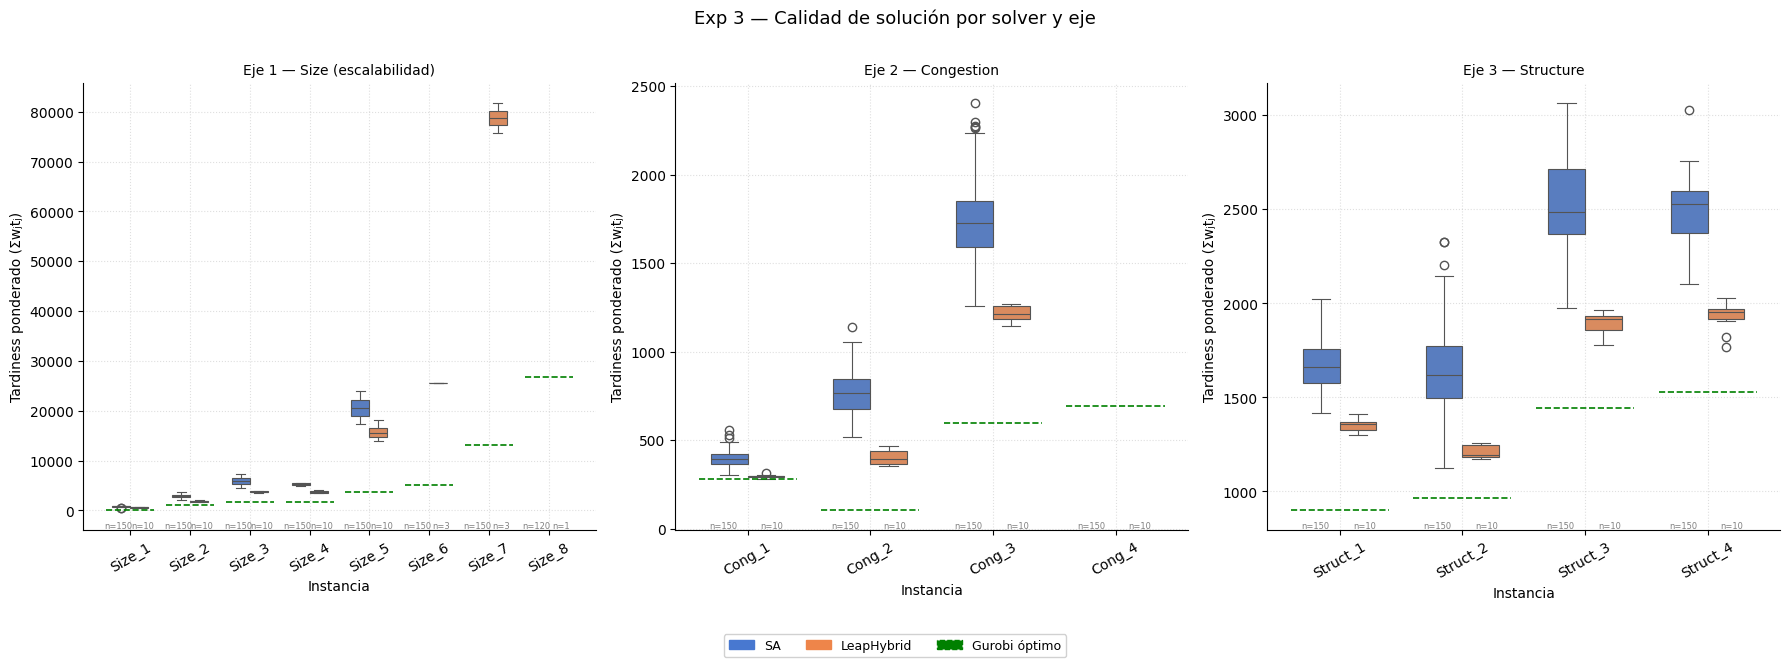

In [16]:
# CELDA 7: PLOT box plots de calidad por eje
# Eje X: instancia, Eje Y: obj_value (solo runs feasibles)
# Línea verde punteada en óptimo Gurobi por instancia

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

SOLVER_COLORS = {"SA": "#4878D0", "LeapHybrid": "#EE854A"}
SOLVER_ORDER  = ["SA", "LeapHybrid"]
AXIS_PLAN     = [
    ("size",  "size_axis",  "Eje 1 — Size (escalabilidad)"),
    ("congestion", "congestion_axis", "Eje 2 — Congestion"),
    ("structure",  "structure_axis",  "Eje 3 — Structure"),
]


def _enrich_with_gurobi(df: pd.DataFrame) -> pd.DataFrame:
    """Une referencia Gurobi al DataFrame de resultados."""
    # Renombrar columnas del df base que choquen con la referencia, para controlar el merge
    df_clean = df.drop(columns=["gurobi_obj", "gurobi_status"], errors="ignore")
    merged = df_clean.merge(
        gurobi_ref[["instance_label", "gurobi_obj", "gurobi_status"]],
        on="instance_label", how="left",
    )
    return merged


fig_boxes, axes_b = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax_b, (axis_name, sheet_name, title) in zip(axes_b, AXIS_PLAN):
    df_b = _metrics_cache.get(sheet_name, pd.DataFrame())
    if df_b.empty:
        df_b = load_existing_runs(FILEPATH, sheet_name)
    if df_b.empty:
        ax_b.set_title(f"{title}\n(sin datos)")
        continue

    df_b = _enrich_with_gurobi(df_b)
    df_feas = df_b[df_b["feasible"].astype(bool)].copy()
    instances_ordered = sorted(df_b["instance_label"].unique())

    if not df_feas.empty:
        sns.boxplot(
            data=df_feas, x="instance_label", y="obj_value", hue="solver",
            order=instances_ordered, hue_order=SOLVER_ORDER,
            palette=SOLVER_COLORS, width=0.6, linewidth=0.8,
            ax=ax_b, showfliers=True,
        )

    # Línea Gurobi por instancia
    x_pos = {lbl: i for i, lbl in enumerate(instances_ordered)}
    gurobi_vals = df_b.drop_duplicates("instance_label").set_index("instance_label")["gurobi_obj"]
    for lbl, g_obj in gurobi_vals.items():
        if pd.notna(g_obj):
            ax_b.hlines(g_obj, x_pos[lbl] - 0.4, x_pos[lbl] + 0.4,
                        colors="green", linewidths=1.2, linestyles="--", zorder=5)

    # Anotar n por solver × instancia (documenta asimetría SA 25 vs LH 10)
    for i, lbl in enumerate(instances_ordered):
        for si, solver_name in enumerate(SOLVER_ORDER):
            n_runs_solver = len(df_b[(df_b["instance_label"] == lbl) &
                                     (df_b["solver"] == solver_name)])
            if n_runs_solver > 0:
                x_offset = -0.2 + si * 0.4
                ax_b.annotate(
                    f"n={n_runs_solver}",
                    xy=(i + x_offset, ax_b.get_ylim()[0]),
                    ha="center", va="bottom", fontsize=6, color="gray",
                )

    ax_b.set_title(title, fontsize=10)
    ax_b.set_xlabel("Instancia")
    ax_b.set_ylabel("Tardiness ponderado (Σwⱼtⱼ)")
    ax_b.tick_params(axis="x", rotation=30)
    ax_b.grid(True, linestyle=":", alpha=0.4)
    sns.despine(ax=ax_b)
    if ax_b.get_legend():
        ax_b.get_legend().remove()

gurobi_patch = mpatches.Patch(color="green", linestyle="--", label="Gurobi óptimo")
sa_patch     = mpatches.Patch(color=SOLVER_COLORS["SA"],        label="SA")
lh_patch     = mpatches.Patch(color=SOLVER_COLORS["LeapHybrid"], label="LeapHybrid")
fig_boxes.suptitle("Exp 3 — Calidad de solución por solver y eje", fontsize=13, y=1.01)
fig_boxes.legend(
    handles=[sa_patch, lh_patch, gurobi_patch],
    loc="lower center", ncol=3, fontsize=9,
    bbox_to_anchor=(0.5, -0.08), framealpha=0.9,
)
plt.tight_layout()
_p = RESULTS_DIR / "exp03_boxplots_quality.png"
fig_boxes.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Guardado: %s", _p)

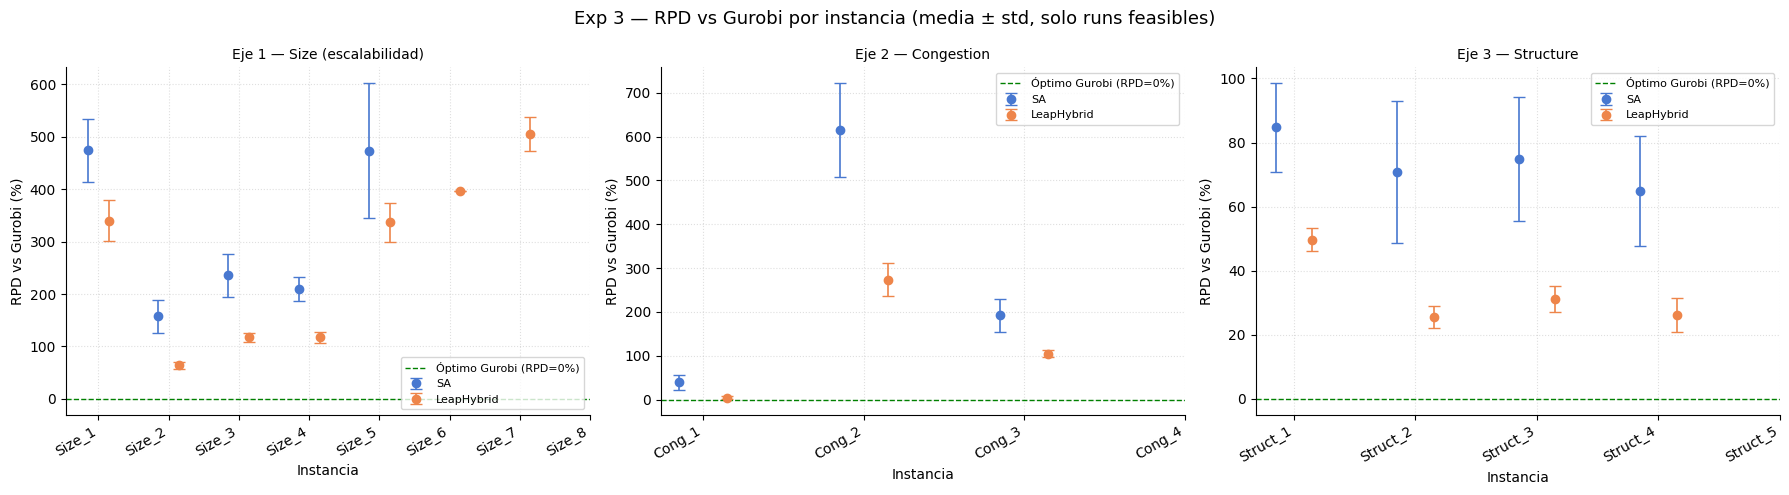

In [17]:
# CELDA 8: PLOT RPD vs Gurobi por instancia (media ± std, SA y LH)

fig_rpd, axes_rpd = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax_r, (axis_name, sheet_name, title) in zip(axes_rpd, AXIS_PLAN):
    df_r = _metrics_cache.get(sheet_name, pd.DataFrame())
    if df_r.empty or "rpd_vs_gurobi" not in df_r.columns:
        ax_r.set_title(f"{title}\n(sin datos RPD)")
        continue

    df_rpd = df_r[df_r["rpd_vs_gurobi"].notna()]
    if df_rpd.empty:
        ax_r.set_title(f"{title}\n(sin RPD feasible)")
        continue

    instances_ordered = sorted(df_r["instance_label"].unique())
    x_pos    = np.arange(len(instances_ordered))
    offsets  = {"SA": -0.15, "LeapHybrid": 0.15}

    for solver_name, color in SOLVER_COLORS.items():
        sub = df_rpd[df_rpd["solver"] == solver_name]
        if sub.empty:
            continue
        agg = (sub.groupby("instance_label")["rpd_vs_gurobi"]
                  .agg(["mean", "std"])
                  .reindex(instances_ordered))
        ax_r.errorbar(
            x_pos + offsets[solver_name], agg["mean"], yerr=agg["std"].fillna(0),
            fmt="o", capsize=4, color=color, label=solver_name, linewidth=1.2,
        )

    ax_r.axhline(0, color="green", linestyle="--", linewidth=1.0, label="Óptimo Gurobi (RPD=0%)")
    ax_r.set_xticks(x_pos)
    ax_r.set_xticklabels(instances_ordered, rotation=30, ha="right")
    ax_r.set_title(title, fontsize=10)
    ax_r.set_xlabel("Instancia")
    ax_r.set_ylabel("RPD vs Gurobi (%)")
    ax_r.legend(fontsize=8)
    ax_r.grid(True, linestyle=":", alpha=0.4)
    sns.despine(ax=ax_r)

fig_rpd.suptitle("Exp 3 — RPD vs Gurobi por instancia (media ± std, solo runs feasibles)", fontsize=13)
plt.tight_layout()
_p = RESULTS_DIR / "exp03_rpd_vs_gurobi.png"
fig_rpd.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Guardado: %s", _p)

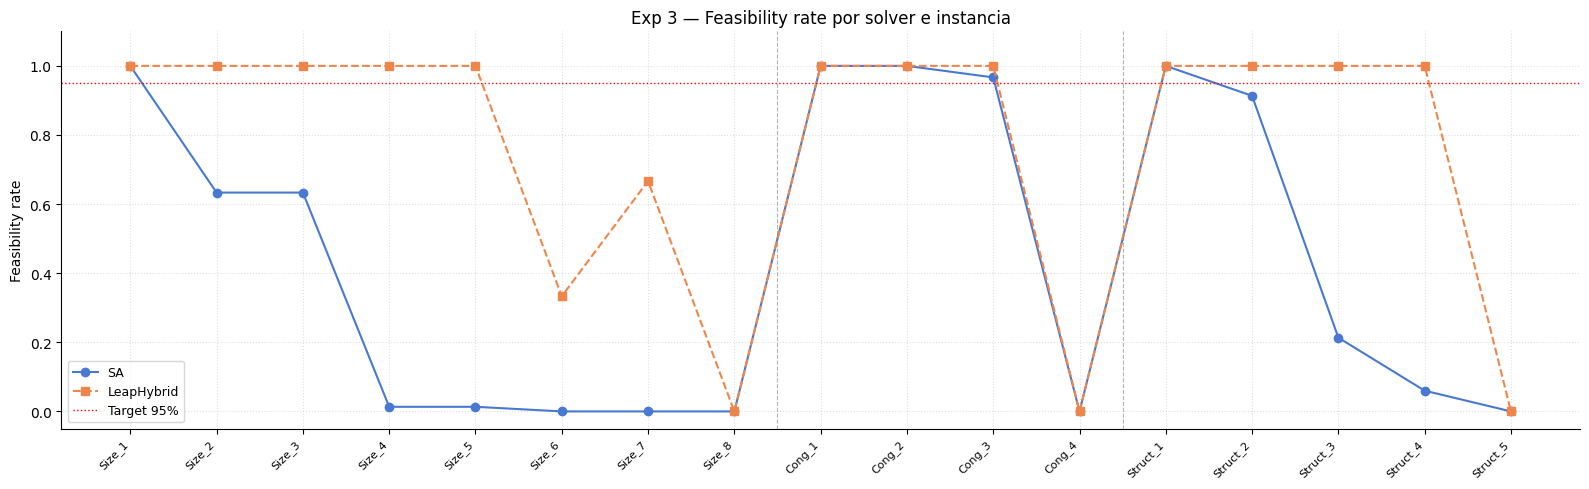

In [18]:
# CELDA 9: PLOT feasibility rate por solver (los tres ejes concatenados)
# Línea punteada roja en el target 95%.

fig_feas, ax_feas = plt.subplots(figsize=(16, 5))

all_labels, all_sa_feas, all_lh_feas = [], [], []
axis_lengths = []

for axis_name, sheet_name, _ in AXIS_PLAN:
    df_f = _metrics_cache.get(sheet_name, pd.DataFrame())
    if df_f.empty:
        df_f = load_existing_runs(FILEPATH, sheet_name)
    lbls_in_axis = sorted(df_f["instance_label"].unique()) if not df_f.empty else []
    axis_lengths.append(len(lbls_in_axis))

    for lbl in lbls_in_axis:
        all_labels.append(lbl)
        sub = df_f[df_f["instance_label"] == lbl]
        sa_sub = sub[sub["solver"] == "SA"]
        lh_sub = sub[sub["solver"] == "LeapHybrid"]
        all_sa_feas.append(sa_sub["feasible"].astype(bool).mean() if not sa_sub.empty else float("nan"))
        all_lh_feas.append(lh_sub["feasible"].astype(bool).mean() if not lh_sub.empty else float("nan"))

x_all = np.arange(len(all_labels))
ax_feas.plot(x_all, all_sa_feas, "o-",  color=SOLVER_COLORS["SA"],         label="SA",         linewidth=1.5)
ax_feas.plot(x_all, all_lh_feas, "s--", color=SOLVER_COLORS["LeapHybrid"], label="LeapHybrid", linewidth=1.5)
ax_feas.axhline(0.95, color="red", linestyle=":", linewidth=1.0, label="Target 95%")

ax_feas.set_xticks(x_all)
ax_feas.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=8)
ax_feas.set_ylabel("Feasibility rate")
ax_feas.set_ylim(-0.05, 1.10)
ax_feas.set_title("Exp 3 — Feasibility rate por solver e instancia")
ax_feas.legend(fontsize=9)
ax_feas.grid(True, linestyle=":", alpha=0.4)

# Separadores de eje
cumsum = 0
for length in axis_lengths[:-1]:
    cumsum += length
    ax_feas.axvline(cumsum - 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

sns.despine(ax=ax_feas)
plt.tight_layout()
_p = RESULTS_DIR / "exp03_feasibility_rate.png"
fig_feas.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Guardado: %s", _p)

In [19]:
# CELDA 9b: GRÁFICO 3a — Tabla resumen de feasibility por (solver, instancia)
#
# Reporta: n_total, n_feasible, feas_rate y flag si feas_rate < 0.80.
# Crítico: el RPD está sesgado si un solver descarta runs por infeasibilidad.
# Una feas_rate < 0.80 indica que el RPD medio no es representativo.

_feas_summary_rows = []
_FEAS_WARNING_THRESHOLD = 0.80

for axis_name, sheet_name, axis_title in AXIS_PLAN:
    df_fs = _metrics_cache.get(sheet_name, pd.DataFrame())
    if df_fs.empty:
        df_fs = load_existing_runs(FILEPATH, sheet_name)
    # También incluir sa_baseline
    df_fs_bl = load_existing_runs(FILEPATH, _SA_BL_SHEET)
    df_fs = pd.concat([df_fs, df_fs_bl], ignore_index=True) if not df_fs_bl.empty else df_fs
    if df_fs.empty:
        continue

    for (inst_lbl, solver_name), grp in df_fs.groupby(["instance_label", "solver"], sort=False):
        n_total_fs  = len(grp)
        n_feas_fs   = int(grp["feasible"].astype(bool).sum())
        feas_rate_fs = n_feas_fs / n_total_fs if n_total_fs > 0 else float("nan")
        low_flag    = (feas_rate_fs < _FEAS_WARNING_THRESHOLD) if not np.isnan(feas_rate_fs) else False
        _feas_summary_rows.append({
            "axis":           axis_name,
            "instance_label": inst_lbl,
            "solver":         solver_name,
            "n_total":        n_total_fs,
            "n_feasible":     n_feas_fs,
            "feas_rate":      round(feas_rate_fs, 4),
            "low_feas_flag":  "⚠ LOW" if low_flag else "",
        })

df_feas_summary = pd.DataFrame(_feas_summary_rows)
print("\n=== GRÁFICO 3a — Tabla resumen de feasibility por (solver, instancia) ===")
print(f"  (Threshold warning: feas_rate < {_FEAS_WARNING_THRESHOLD:.0%})")
if not df_feas_summary.empty:
    print(df_feas_summary.to_string(index=False))
    _n_low = int((df_feas_summary["low_feas_flag"] == "⚠ LOW").sum())
    if _n_low > 0:
        logger.warning(
            "%d combinaciones (solver, instancia) con feas_rate < %.0f%% — "
            "RPD para esas celdas está sesgado.",
            _n_low, _FEAS_WARNING_THRESHOLD * 100,
        )
else:
    print("  (sin datos)")


=== GRÁFICO 3a — Tabla resumen de feasibility por (solver, instancia) ===
  (Threshold warning: feas_rate < 80%)
      axis instance_label     solver  n_total  n_feasible  feas_rate low_feas_flag
      size         Size_1         SA      175         175     1.0000              
      size         Size_2         SA      175         112     0.6400         ⚠ LOW
      size         Size_3         SA      150          95     0.6333         ⚠ LOW
      size         Size_4         SA      150           2     0.0133         ⚠ LOW
      size         Size_5         SA      150           2     0.0133         ⚠ LOW
      size         Size_6         SA      150           0     0.0000         ⚠ LOW
      size         Size_7         SA      150           0     0.0000         ⚠ LOW
      size         Size_8         SA      120           0     0.0000         ⚠ LOW
      size         Size_1 LeapHybrid       10          10     1.0000              
      size         Size_2 LeapHybrid       10          1

In [20]:
# CELDA 10: TABLA RESUMEN — hallazgos clave consolidados por solver e instancia
#
# Columnas: instance_label | solver | n_runs | feas_rate | obj_mean | obj_std |
#           rpd_mean | wall_time_mean | rpd_h2h
# Imprime en consola con formato tabular. Listo para copiar a la tesis.

_SUMMARY_COLS = [
    "instance_label", "solver", "n_runs", "feas_rate",
    "obj_mean", "obj_std", "rpd_mean", "wall_time_mean", "rpd_h2h",
]

_summary_rows = []

for axis_name, sheet_name, axis_title in AXIS_PLAN:
    df_s = _metrics_cache.get(sheet_name, pd.DataFrame())
    if df_s.empty:
        df_s = load_existing_runs(FILEPATH, sheet_name)
    if df_s.empty:
        continue

    for (lbl, solver), grp in df_s.groupby(["instance_label", "solver"], sort=False):
        feas      = grp["feasible"].astype(bool)
        n_runs    = len(grp)
        feas_rate = float(feas.mean())
        obj_vals  = grp.loc[feas, "obj_value"].dropna()
        obj_mean  = float(obj_vals.mean()) if not obj_vals.empty else float("nan")
        obj_std   = float(obj_vals.std())  if len(obj_vals) > 1  else float("nan")
        rpd_vals  = grp.loc[feas, "rpd_vs_gurobi"].dropna()
        rpd_mean  = float(rpd_vals.mean()) if not rpd_vals.empty else float("nan")
        wt_mean   = float(grp["wall_time_s"].mean())
        # rpd_h2h: solo tiene valor en filas LH (SA tiene NaN por diseño)
        h2h_vals  = grp["rpd_h2h"].dropna()
        rpd_h2h   = float(h2h_vals.mean()) if not h2h_vals.empty else float("nan")

        _summary_rows.append({
            "axis":           axis_name,
            "instance_label": lbl,
            "solver":         solver,
            "n_runs":         n_runs,
            "feas_rate":      round(feas_rate, 4),
            "obj_mean":       round(obj_mean, 2) if not pd.isna(obj_mean) else float("nan"),
            "obj_std":        round(obj_std,  2) if not pd.isna(obj_std)  else float("nan"),
            "rpd_mean":       round(rpd_mean, 2) if not pd.isna(rpd_mean) else float("nan"),
            "wall_time_mean": round(wt_mean,  2),
            "rpd_h2h":        round(rpd_h2h,  2) if not pd.isna(rpd_h2h)  else float("nan"),
        })

df_summary = pd.DataFrame(_summary_rows).sort_values(["axis", "instance_label", "solver"])

for axis_name, axis_title in [("size", "Eje 1 — Size"), ("dens", "Eje 2 — Dens"), ("slack", "Eje 3 — Slack")]:
    sub = df_summary[df_summary["axis"] == axis_name][_SUMMARY_COLS]
    print(f"\n{'='*80}")
    print(f"  {axis_title}")
    print(f"{'='*80}")
    print(sub.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Guardar tabla en hoja resumen del Excel
_summary_out = df_summary[["axis"] + _SUMMARY_COLS]
from openpyxl import load_workbook
_wb = load_workbook(FILEPATH)
if "summary" in _wb.sheetnames:
    del _wb["summary"]
_wb.save(FILEPATH)
append_rows(FILEPATH, "summary", _summary_out.to_dict(orient="records"))
logger.info("Tabla resumen guardada en hoja 'summary' de %s", FILEPATH)


  Eje 1 — Size
instance_label     solver  n_runs  feas_rate  obj_mean  obj_std  rpd_mean  wall_time_mean  rpd_h2h
        Size_1 LeapHybrid      10       1.00    588.90    52.18    339.85            9.13   -23.39
        Size_1         SA     150       1.00    768.70    80.10    474.14            2.05      NaN
        Size_2 LeapHybrid      10       1.00   1836.15    79.82     64.06           16.25   -36.25
        Size_2         SA     150       0.63   2880.33   355.58    157.36            4.53      NaN
        Size_3 LeapHybrid      10       1.00   3789.95   147.01    117.48           23.74   -35.16
        Size_3         SA     150       0.63   5845.05   725.08    235.41            9.48      NaN
        Size_4 LeapHybrid      10       1.00   3678.98   181.50    117.19           28.99   -30.03
        Size_4         SA     150       0.01   5257.91   389.58    210.40           25.91      NaN
        Size_5 LeapHybrid      10       1.00  15702.33  1329.13    337.08           66.24   -


=== COMPARACIÓN 4 SOLVERS (instancias plan LH) ===
instance_label      solver  n_runs  feas_rate  obj_mean  obj_std  rpd_vs_gurobi_milp  gurobi_milp_obj
        Cong_1 Gurobi-MILP       5       1.00    283.32      NaN                0.00           283.32
        Cong_1  LeapHybrid      10       1.00    295.92     8.70                4.45           283.32
        Cong_1          SA      25       1.00    399.37    48.93               40.96           283.32
        Cong_3 Gurobi-MILP       5       1.00    594.73      NaN                0.00           594.73
        Cong_3  LeapHybrid      10       1.00   1215.25    45.38              104.34           594.73
        Cong_3          SA      25       0.96   1724.56   190.47              189.97           594.73
        Cong_4 Gurobi-MILP       5       1.00    690.61      NaN                0.00           690.61
        Cong_4  LeapHybrid      10       0.00       NaN      NaN                 NaN           690.61
        Cong_4          SA    

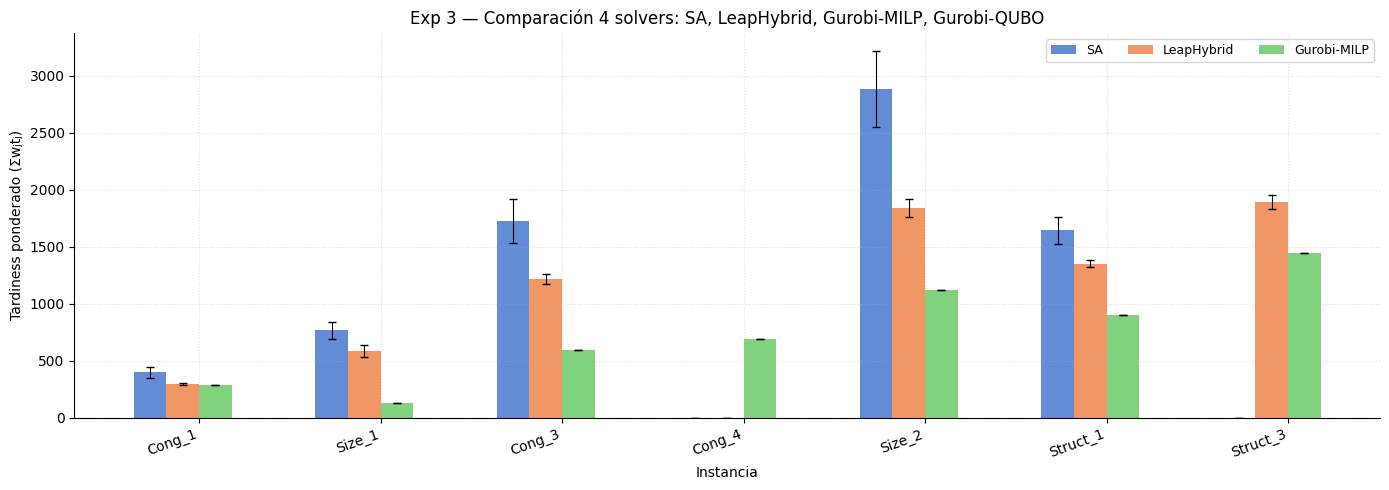

In [21]:
# CELDA 11: COMPARACIÓN 4 SOLVERS — instancias del plan LH
#
# Une datos de:
#   1. SA          — hoja sa_baseline (este experimento)
#   2. LeapHybrid  — hojas size_axis / congestion_axis / structure_axis (este experimento)
#   3. Gurobi-MILP — exp01_gurobi_baseline.xlsx hoja raw_runs
#   4. Gurobi-QUBO — exp01_gurobi_baseline.xlsx hoja milp_qubo_equiv (si existe)
# RPD calculado vs Gurobi-MILP óptimo (gold standard).

_LH_LABELS = [lbl for lbl, _ in _SA_BL_PLAN]  # mismas 7 instancias

_df_sa_bl = load_existing_runs(FILEPATH, _SA_BL_SHEET)
_df_lh_all = pd.concat(
    [
        load_existing_runs(FILEPATH, sh)
        for sh in ("size_axis", "congestion_axis", "structure_axis")
        if not load_existing_runs(FILEPATH, sh).empty
    ],
    ignore_index=True,
) if any(
    not load_existing_runs(FILEPATH, sh).empty
    for sh in ("size_axis", "congestion_axis", "structure_axis")
) else pd.DataFrame()

# LeapHybrid rows filtered to the 7 plan instances
if not _df_lh_all.empty:
    _df_lh_plan = _df_lh_all[
        (_df_lh_all["solver"] == "LeapHybrid") &
        (_df_lh_all["instance_label"].isin(_LH_LABELS))
    ].copy()
else:
    _df_lh_plan = pd.DataFrame()

# Gurobi-QUBO equivalence results
_EXP1_EQUIV_PATH = EXP1_PATH
try:
    _df_gqubo = pd.read_excel(_EXP1_EQUIV_PATH, sheet_name="milp_qubo_equiv")
    if _df_gqubo.empty:
        _df_gqubo = pd.DataFrame()
except Exception:
    _df_gqubo = pd.DataFrame()

# Build the 4-solver comparison table
_solver_rows_4 = []

def _add_rows_for_solver(df: pd.DataFrame, solver_name: str) -> None:
    if df.empty:
        return
    sub = df[df["instance_label"].isin(_LH_LABELS)].copy()
    for lbl in _LH_LABELS:
        grp = sub[sub["instance_label"] == lbl]
        if grp.empty:
            continue
        if "feasible" in grp.columns:
            feas_vals = grp["feasible"].astype(bool)
            obj_vals  = grp.loc[feas_vals, "obj_value"].dropna()
        else:
            obj_vals  = grp["qubo_gurobi_obj"].dropna() if "qubo_gurobi_obj" in grp.columns else pd.Series(dtype=float)
            feas_vals = obj_vals.notna()
        obj_col = "qubo_gurobi_obj" if "qubo_gurobi_obj" in grp.columns else "obj_value"
        if obj_col == "qubo_gurobi_obj":
            obj_vals = grp[obj_col].dropna()
        n_runs    = len(grp)
        feas_rate = float(grp["feasible"].astype(bool).mean()) if "feasible" in grp.columns else float(len(obj_vals) > 0)
        obj_mean  = float(obj_vals.mean()) if not obj_vals.empty else float("nan")
        obj_std   = float(obj_vals.std())  if len(obj_vals) > 1  else float("nan")
        g_obj = gurobi_ref.loc[gurobi_ref["instance_label"] == lbl, "gurobi_obj"]
        g_obj_val = float(g_obj.iloc[0]) if not g_obj.empty else float("nan")
        rpd = (100.0 * (obj_mean - g_obj_val) / g_obj_val
               if not np.isnan(obj_mean) and not np.isnan(g_obj_val) and g_obj_val > 0
               else float("nan"))
        _solver_rows_4.append({
            "instance_label": lbl,
            "solver": solver_name,
            "n_runs": n_runs,
            "feas_rate": round(feas_rate, 4),
            "obj_mean": round(obj_mean, 2) if not np.isnan(obj_mean) else float("nan"),
            "obj_std":  round(obj_std,  2) if not np.isnan(obj_std)  else float("nan"),
            "rpd_vs_gurobi_milp": round(rpd, 2) if not np.isnan(rpd) else float("nan"),
            "gurobi_milp_obj": round(g_obj_val, 2) if not np.isnan(g_obj_val) else float("nan"),
        })

_add_rows_for_solver(_df_sa_bl, "SA")
_add_rows_for_solver(_df_lh_plan, "LeapHybrid")

# Gurobi-MILP: one row per instance, best_obj from exp1
for lbl in _LH_LABELS:
    g_row = gurobi_ref[gurobi_ref["instance_label"] == lbl]
    if g_row.empty:
        continue
    g_obj_v = float(g_row["gurobi_obj"].iloc[0])
    _solver_rows_4.append({
        "instance_label": lbl,
        "solver": "Gurobi-MILP",
        "n_runs": 5,
        "feas_rate": 1.0,
        "obj_mean": round(g_obj_v, 2),
        "obj_std":  float("nan"),
        "rpd_vs_gurobi_milp": 0.0,
        "gurobi_milp_obj": round(g_obj_v, 2),
    })

# Gurobi-QUBO
if not _df_gqubo.empty:
    for lbl in _LH_LABELS:
        g_row_q = _df_gqubo[_df_gqubo["instance_label"] == lbl]
        if g_row_q.empty:
            continue
        q_obj = g_row_q["qubo_gurobi_obj"].dropna()
        g_milp_v = gurobi_ref.loc[gurobi_ref["instance_label"] == lbl, "gurobi_obj"]
        g_milp_val = float(g_milp_v.iloc[0]) if not g_milp_v.empty else float("nan")
        obj_mean_q = float(q_obj.mean()) if not q_obj.empty else float("nan")
        rpd_q = (100.0 * (obj_mean_q - g_milp_val) / g_milp_val
                 if not np.isnan(obj_mean_q) and not np.isnan(g_milp_val) and g_milp_val > 0
                 else float("nan"))
        _solver_rows_4.append({
            "instance_label": lbl,
            "solver": "Gurobi-QUBO",
            "n_runs": len(g_row_q),
            "feas_rate": float(g_row_q["is_feasible_bqp"].astype(bool).mean()) if "is_feasible_bqp" in g_row_q.columns else float("nan"),
            "obj_mean": round(obj_mean_q, 2) if not np.isnan(obj_mean_q) else float("nan"),
            "obj_std":  float("nan"),
            "rpd_vs_gurobi_milp": round(rpd_q, 2) if not np.isnan(rpd_q) else float("nan"),
            "gurobi_milp_obj": round(g_milp_val, 2) if not np.isnan(g_milp_val) else float("nan"),
        })

_df_4s = pd.DataFrame(_solver_rows_4)
if not _df_4s.empty:
    print("\n=== COMPARACIÓN 4 SOLVERS (instancias plan LH) ===")
    print(_df_4s.sort_values(["instance_label", "solver"]).to_string(index=False))

    # Box plot 4 solvers side by side
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns

    _SOLVER_COLORS_4 = {
        "SA":          "#4878D0",
        "LeapHybrid":  "#EE854A",
        "Gurobi-MILP": "#6ACC65",
        "Gurobi-QUBO": "#D65F5F",
    }
    _SOLVER_ORDER_4 = ["SA", "LeapHybrid", "Gurobi-MILP", "Gurobi-QUBO"]
    _instances_order_4 = _LH_LABELS

    fig_4s, ax_4s = plt.subplots(figsize=(14, 5))
    x_pos_4 = np.arange(len(_instances_order_4))
    n_solvers_4 = len(_SOLVER_ORDER_4)
    bar_w = 0.18

    for si, solver_name in enumerate(_SOLVER_ORDER_4):
        sub_s = _df_4s[_df_4s["solver"] == solver_name]
        if sub_s.empty:
            continue
        ys = []
        yerrs = []
        for lbl in _instances_order_4:
            r = sub_s[sub_s["instance_label"] == lbl]
            ys.append(float(r["obj_mean"].iloc[0]) if not r.empty and not np.isnan(float(r["obj_mean"].iloc[0])) else 0)
            yerrs.append(float(r["obj_std"].iloc[0]) if not r.empty and not np.isnan(float(r["obj_std"].iloc[0]) if not r.empty else float("nan")) else 0)
        offset = (si - (n_solvers_4 - 1) / 2) * bar_w
        ax_4s.bar(x_pos_4 + offset, ys, width=bar_w,
                  color=_SOLVER_COLORS_4[solver_name], label=solver_name, alpha=0.85)
        ax_4s.errorbar(x_pos_4 + offset, ys, yerr=yerrs,
                       fmt="none", color="black", capsize=3, linewidth=0.8)

    ax_4s.set_xticks(x_pos_4)
    ax_4s.set_xticklabels(_instances_order_4, rotation=20, ha="right")
    ax_4s.set_xlabel("Instancia")
    ax_4s.set_ylabel("Tardiness ponderado (Σwⱼtⱼ)")
    ax_4s.set_title("Exp 3 — Comparación 4 solvers: SA, LeapHybrid, Gurobi-MILP, Gurobi-QUBO")
    ax_4s.legend(ncol=4, fontsize=9)
    ax_4s.grid(True, linestyle=":", alpha=0.4)
    sns.despine(ax=ax_4s)
    plt.tight_layout()
    _p4 = RESULTS_DIR / "exp03_4solver_comparison.png"
    fig_4s.savefig(_p4, dpi=300, bbox_inches="tight")
    plt.show()
    logger.info("Guardado: %s", _p4)

logger.info("Exp 3 completo. Resultados en: %s", FILEPATH)